In [38]:
#imports
from pathlib import Path
from collections import Counter

from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
#file path
XML_FILE = Path("../data/dblp.xml")

print("File exists:", XML_FILE.exists())
print("File:", XML_FILE)

File exists: True
File: ..\data\dblp.xml


In [40]:
#Confirm structure
with open(XML_FILE, "rb") as f:
    first_lines = [f.readline() for _ in range(30)]

for line in first_lines:
    print(line.decode("utf-8", errors="replace").rstrip())

<?xml version="1.0" encoding="ISO-8859-1"?>
<!DOCTYPE dblp SYSTEM "dblp.dtd">
<dblp>
<article mdate="2020-06-25" key="tr/meltdown/s18" publtype="informal">
<author>Paul Kocher</author>
<author>Daniel Genkin</author>
<author>Daniel Gruss</author>
<author>Werner Haas 0004</author>
<author>Mike Hamburg</author>
<author>Moritz Lipp</author>
<author>Stefan Mangard</author>
<author>Thomas Prescher 0002</author>
<author>Michael Schwarz 0001</author>
<author>Yuval Yarom</author>
<title>Spectre Attacks: Exploiting Speculative Execution.</title>
<journal>meltdownattack.com</journal>
<year>2018</year>
<ee type="oa">https://spectreattack.com/spectre.pdf</ee>
</article>
<article mdate="2020-06-25" key="tr/meltdown/m18" publtype="informal">
<author>Moritz Lipp</author>
<author>Michael Schwarz 0001</author>
<author>Daniel Gruss</author>
<author>Thomas Prescher 0002</author>
<author>Werner Haas 0004</author>
<author>Stefan Mangard</author>
<author>Paul Kocher</author>
<author>Daniel Genkin</author>
<a

In [41]:
#Publication types and their count
parser = etree.XMLParser(
    load_dtd=True,
    resolve_entities=True,
    # recover=True
)

publication_types = Counter()

with open(XML_FILE, "rb") as f:
    context = etree.iterparse(
        f,
        events=("end",),
        tag={
            "article",
            "inproceedings",
            "proceedings",
            "book",
            "incollection",
            "phdthesis",
            "mastersthesis",
            "www"
        },
        recover=True
    )

    for event, elem in context:
        publication_types[elem.tag] += 1
        elem.clear()

        while elem.getprevious() is not None:
            del elem.getparent()[0]

print(publication_types)

Counter({'inproceedings': 3201080, 'www': 3190713, 'article': 3084699, 'phdthesis': 105415, 'incollection': 69544, 'proceedings': 53833, 'book': 19785, 'mastersthesis': 16})


In [42]:
context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag="article"
)

for event, elem in context:
    if elem.get("key") == "tr/ibm/LILOG1a":
        print("TITLE:", repr(elem.findtext("title")))

        for author in elem.findall("author"):
            print("AUTHOR:", repr(author.text))

        break

TITLE: 'LILOG - Linguistische und logische Methoden f'
AUTHOR: 'Otthein Herzog'
AUTHOR: 'Claus-Rainer Rollinger'
AUTHOR: 'Peter H. Schmitt'
AUTHOR: 'Petra Steffens'
AUTHOR: 'Rudi Studer'
AUTHOR: 'Birgit Wesche'
AUTHOR: 'Brigitte Bartsch-Sp'
AUTHOR: 'F. G'
AUTHOR: 'Christopher Habel'
AUTHOR: 'Siegfried Kanngie'
AUTHOR: 'Christian Rohrer'


In [43]:
#type table
type_df = pd.DataFrame(
    publication_types.items(),
    columns=["publication_type", "count"]
).sort_values(
    "count",
    ascending=False
)

type_df

,publication_type,count
3,inproceedings,3201080
4,www,3190713
0,article,3084699
7,phdthesis,105415
6,incollection,69544
2,proceedings,53833
1,book,19785
5,mastersthesis,16


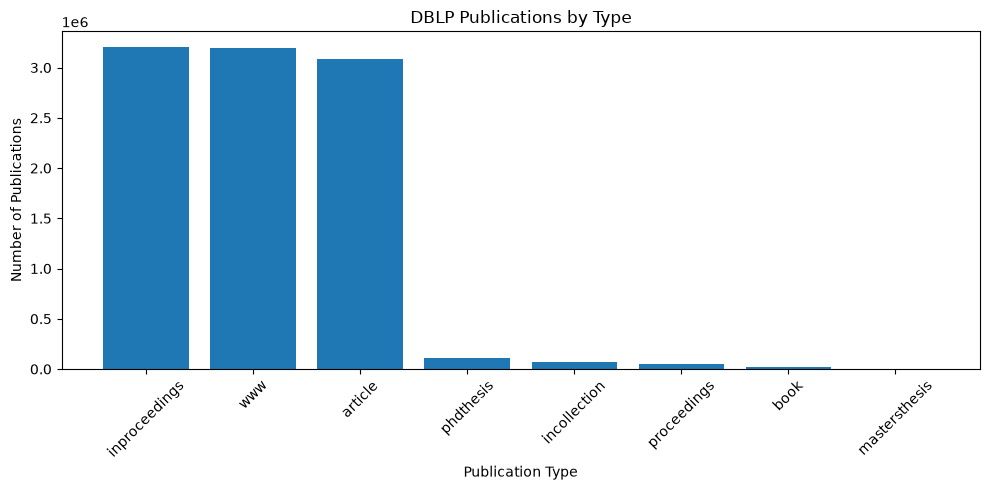

In [44]:
plt.figure(figsize=(10, 5))

plt.bar(
    type_df["publication_type"],
    type_df["count"]
)

plt.xlabel("Publication Type")
plt.ylabel("Number of Publications")
plt.title("DBLP Publications by Type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
#publication types
samples = []

context = etree.iterparse(
    str(XML_FILE),
    events=("end",)
)

for event, elem in context:

    if elem.tag in {
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    }:

        samples.append(elem)

        if len(samples) >= 10:
            break

In [46]:
#visualize publication structures
for i, record in enumerate(samples):

    print("=" * 70)
    print(f"RECORD {i + 1}")
    print("=" * 70)

    print("Type:", record.tag)
    print("Key:", record.get("key"))
    print("Fields:")

    for child in record:
        print(f"  {child.tag}: {child.text}")

RECORD 1
Type: article
Key: tr/meltdown/s18
Fields:
  author: Paul Kocher
  author: Daniel Genkin
  author: Daniel Gruss
  author: Werner Haas 0004
  author: Mike Hamburg
  author: Moritz Lipp
  author: Stefan Mangard
  author: Thomas Prescher 0002
  author: Michael Schwarz 0001
  author: Yuval Yarom
  title: Spectre Attacks: Exploiting Speculative Execution.
  journal: meltdownattack.com
  year: 2018
  ee: https://spectreattack.com/spectre.pdf
RECORD 2
Type: article
Key: tr/meltdown/m18
Fields:
  author: Moritz Lipp
  author: Michael Schwarz 0001
  author: Daniel Gruss
  author: Thomas Prescher 0002
  author: Werner Haas 0004
  author: Stefan Mangard
  author: Paul Kocher
  author: Daniel Genkin
  author: Yuval Yarom
  author: Mike Hamburg
  title: Meltdown
  journal: meltdownattack.com
  ee: https://meltdownattack.com/meltdown.pdf
  year: 2018
RECORD 3
Type: book
Key: tr/acm/CS2013
Fields:
  title: Computer Science Curricula 2013
  publisher: ACM Press and IEEE Computer Society Press

In [47]:
record = samples[0]

authors = record.findall("author")

print("Number of authors:", len(authors))

for author in authors:
    print(author.text)

Number of authors: 10
Paul Kocher
Daniel Genkin
Daniel Gruss
Werner Haas 0004
Mike Hamburg
Moritz Lipp
Stefan Mangard
Thomas Prescher 0002
Michael Schwarz 0001
Yuval Yarom


In [48]:
journal = record.findtext("journal")
booktitle = record.findtext("booktitle")

print("Journal:", journal)
print("Booktitle:", booktitle)

Journal: meltdownattack.com
Booktitle: None


In [49]:
#publications per year
from collections import Counter

year_counts = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:
    year = elem.findtext("year")

    if year:
        year_counts[year] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Number of different years:", len(year_counts))
print("Earliest year:", min(year_counts))
print("Latest year:", max(year_counts))

Number of different years: 88
Earliest year: 1936
Latest year: 2023


In [50]:
#year counts
year_counts = dict(sorted(year_counts.items()))

for year, count in year_counts.items():
    print(year, ":", count)

1936 : 12
1937 : 16
1938 : 11
1939 : 18
1940 : 10
1941 : 13
1942 : 13
1943 : 8
1944 : 5
1945 : 9
1946 : 31
1947 : 10
1948 : 41
1949 : 52
1950 : 28
1951 : 41
1952 : 111
1953 : 171
1954 : 215
1955 : 205
1956 : 349
1957 : 338
1958 : 455
1959 : 707
1960 : 610
1961 : 893
1962 : 1171
1963 : 1017
1964 : 1087
1965 : 1274
1966 : 1481
1967 : 1747
1968 : 2163
1969 : 2088
1970 : 2183
1971 : 3093
1972 : 3707
1973 : 4393
1974 : 4983
1975 : 5212
1976 : 5648
1977 : 5929
1978 : 6750
1979 : 6876
1980 : 7758
1981 : 8633
1982 : 9912
1983 : 10826
1984 : 12294
1985 : 13850
1986 : 16437
1987 : 17490
1988 : 21562
1989 : 23975
1990 : 28017
1991 : 30942
1992 : 34711
1993 : 40487
1994 : 44898
1995 : 47319
1996 : 52475
1997 : 56720
1998 : 63950
1999 : 70718
2000 : 79855
2001 : 86572
2002 : 97411
2003 : 115566
2004 : 135028
2005 : 157372
2006 : 175615
2007 : 189223
2008 : 202843
2009 : 222233
2010 : 228310
2011 : 249950
2012 : 262345
2013 : 279377
2014 : 291083
2015 : 300810
2016 : 312906
2017 : 336993
2018 : 3712

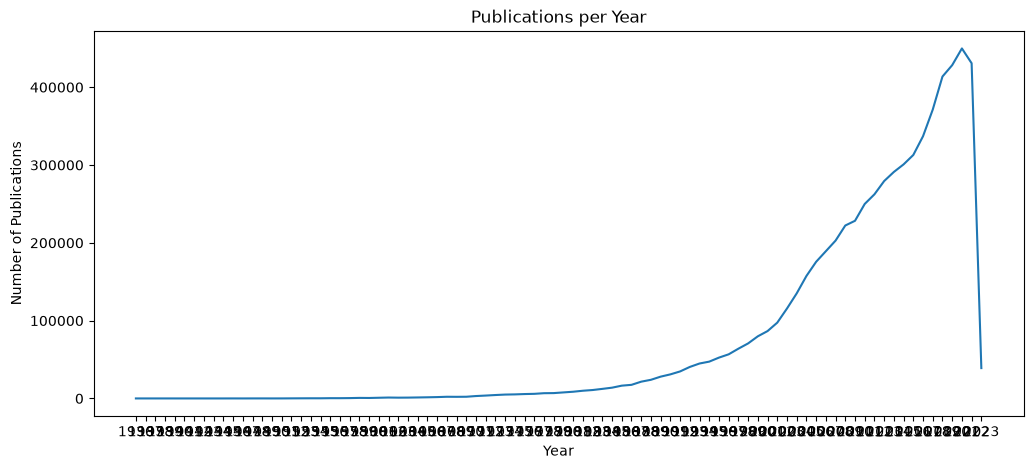

In [51]:
import matplotlib.pyplot as plt

years = list(year_counts.keys())
counts = list(year_counts.values())

plt.figure(figsize=(12, 5))
plt.plot(years, counts)

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publications per Year")

plt.show()

In [52]:
#check missing fields
from collections import Counter

missing_counts = Counter()
total_records = 0

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:
    total_records += 1

    fields = {
        "author": elem.findall("author"),
        "title": elem.find("title"),
        "year": elem.find("year"),
    }

    # Check whether each field is missing
    if not fields["author"]:
        missing_counts["author"] += 1

    if fields["title"] is None or not fields["title"].text:
        missing_counts["title"] += 1

    if fields["year"] is None or not fields["year"].text:
        missing_counts["year"] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Total records:", total_records)
print("\nMissing fields:")

for field, count in missing_counts.items():
    print(f"{field}: {count}")

Total records: 9725085

Missing fields:
author: 89877
title: 7801
year: 3190700


In [53]:
#missing years by publication type
from collections import defaultdict

missing_year_by_type = defaultdict(int)
total_by_type = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:
    pub_type = elem.tag
    total_by_type[pub_type] += 1

    if elem.find("year") is None:
        missing_year_by_type[pub_type] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

for pub_type in total_by_type:
    print(
        pub_type,
        "→ total:", total_by_type[pub_type],
        "| missing year:", missing_year_by_type[pub_type]
    )

article → total: 3084699 | missing year: 3
book → total: 19785 | missing year: 0
proceedings → total: 53833 | missing year: 0
inproceedings → total: 3201080 | missing year: 0
www → total: 3190713 | missing year: 3190697
mastersthesis → total: 16 | missing year: 0
incollection → total: 69544 | missing year: 0
phdthesis → total: 105415 | missing year: 0


In [54]:
#check what the www records have
www_samples = []

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag="www",
    recover=True
)

for event, elem in context:
    www_samples.append(elem)

    if len(www_samples) >= 5:
        break

for i, record in enumerate(www_samples):
    print("=" * 60)
    print(f"WWW RECORD {i + 1}")
    print("=" * 60)

    print("Key:", record.get("key"))

    for child in record:
        print(f"{child.tag}: {child.text}")

WWW RECORD 1
Key: www/org/w3/style-xsl
title: W3C: Extensible Stylesheet Language (XSL)
ee: http://www.w3.org/Style/XSL/
year: 2001
WWW RECORD 2
Key: www/org/w3/http1-1
author: Roy T. Fielding
author: Henrik Frystyk Nielsen
author: Tim Berners-Lee
title: Internet Draft: Hypertext Transfer Protocol - HTTP/1.1
ee: http://www.w3.org/Protocols/HTTP/1.1/spec.html
year: 1999
WWW RECORD 3
Key: www/org/w3/dom
title: W3C: Document Oject Model (DOM)
ee: http://www.w3.org/DOM/
year: 1997
WWW RECORD 4
Key: www/org/w3/TR/query-datamodel
editor: Mary F. Fernandez
editor: Jonathan Robie
title: XML Query Data Model
year: 2001
ee: http://www.w3.org/TR/query-datamodel
WWW RECORD 5
Key: www/org/w3/TR/REC-xml
title: W3C: Extensible Markup Language (XML) 1.0 - first edition.
ee: https://www.w3.org/TR/xml/
year: 1998


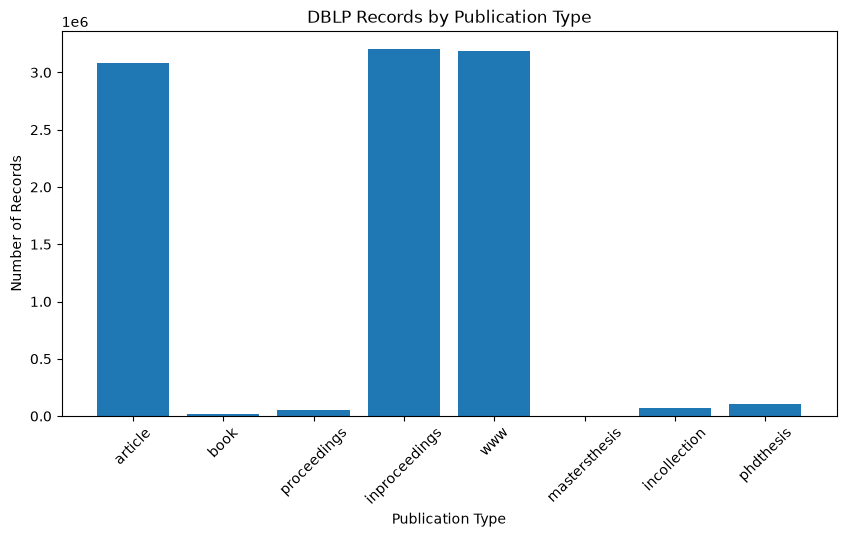

In [55]:
#Publication type distribution
import matplotlib.pyplot as plt

types = list(total_by_type.keys())
counts = list(total_by_type.values())

plt.figure(figsize=(10, 5))
plt.bar(types, counts)

plt.xlabel("Publication Type")
plt.ylabel("Number of Records")
plt.title("DBLP Records by Publication Type")
plt.xticks(rotation=45)

plt.show()

In [56]:
#authors per publication
author_count_distribution = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:

    number_of_authors = len(elem.findall("author"))

    author_count_distribution[number_of_authors] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Authors per publication:")

for number_of_authors, number_of_publications in sorted(author_count_distribution.items()):
    print(
        number_of_authors,
        "authors →",
        number_of_publications,
        "publications"
    )

Authors per publication:
0 authors → 89877 publications
1 authors → 4100703 publications
2 authors → 1684304 publications
3 authors → 1574024 publications
4 authors → 1062581 publications
5 authors → 588787 publications
6 authors → 308509 publications
7 authors → 140754 publications
8 authors → 72096 publications
9 authors → 37965 publications
10 authors → 22170 publications
11 authors → 12655 publications
12 authors → 8314 publications
13 authors → 5414 publications
14 authors → 3704 publications
15 authors → 2638 publications
16 authors → 1916 publications
17 authors → 1429 publications
18 authors → 1141 publications
19 authors → 981 publications
20 authors → 726 publications
21 authors → 572 publications
22 authors → 450 publications
23 authors → 390 publications
24 authors → 343 publications
25 authors → 317 publications
26 authors → 233 publications
27 authors → 202 publications
28 authors → 194 publications
29 authors → 162 publications
30 authors → 151 publications
31 authors → 

In [57]:
#449 AUTHORS???
context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:

    authors = elem.findall("author")

    if len(authors) >= 400:
        print("=" * 70)
        print("TYPE:", elem.tag)
        print("KEY:", elem.get("key"))
        print("TITLE:", elem.findtext("title"))
        print("YEAR:", elem.findtext("year"))
        print("NUMBER OF AUTHORS:", len(authors))
        print("FIRST 10 AUTHORS:")

        for author in authors[:10]:
            print(" ", author.text)

        print("LAST 10 AUTHORS:")

        for author in authors[-10:]:
            print(" ", author.text)

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

TYPE: article
KEY: journals/nature/TurroAMGGSASFTS20
TITLE: Whole-genome sequencing of patients with rare diseases in a national health system.
YEAR: 2020
NUMBER OF AUTHORS: 449
FIRST 10 AUTHORS:
  Ernest Turro
  William J. Astle
  Karyn Megy
  Stefan Gr
  Daniel Greene
  Olga Shamardina
  Hana Lango Allen
  Alba Sanchis-Juan
  Mattia Frontini
  Chantal Thys
LAST 10 AUTHORS:
  Emma R. Woodward
  Stephen J. Wort
  Austen Worth
  Michael Wright
  Katherine Yates
  Patrick F. K. Yong
  Timothy Young
  Ping Yu
  Patrick Yu-Wai-Man
  Eliska Zlamalova


In [58]:
#count author appearances
author_counts = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:

    for author in elem.findall("author"):
        if author.text:
            author_counts[author.text] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Number of unique author names:", len(author_counts))

print("\nTop 20 authors:")
for author, count in author_counts.most_common(20):
    print(author, "→", count)

Number of unique author names: 3166626

Top 20 authors:
Jos → 69606
J → 49687
Andr → 30382
Jo → 24002
G → 22074
S → 20900
Fran → 17824
Mar → 16210
C → 15839
Fr → 14080
M → 12911
St → 12213
R → 12045
V → 11832
Jes → 11432
H → 11204
Bj → 9724
Lu → 8909
Ren → 8161
Tom → 7513


In [59]:
context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

found = 0

for event, elem in context:

    for author in elem.findall("author"):
        if author.text == "Jos":
            print("=" * 70)
            print("KEY:", elem.get("key"))
            print("TITLE:", elem.findtext("title"))
            print("YEAR:", elem.findtext("year"))
            print("AUTHORS:")

            for a in elem.findall("author"):
                print(" ", repr(a.text))

            found += 1
            break

    if found >= 5:
        break

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("\nFound:", found)

KEY: reference/genetic/LunaCV15
TITLE: Genetic Programming for Mining Association Rules in Relational Database Environments.
YEAR: 2015
AUTHORS:
  'Jos'
  'Alberto Cano 0001'
  'Sebasti'
KEY: reference/genetic/RibeiroNVZ15
TITLE: eCrash: a Genetic Programming-Based Testing Tool for Object-Oriented Software.
YEAR: 2015
AUTHORS:
  'Jos'
  'Ana Filipa Nogueira'
  'Francisco Fern'
  'M'
KEY: reference/assisted/YanguasU12
TITLE: Housing, Gerontology and AAL: New Services Development.
YEAR: 2012
AUTHORS:
  'Jos'
  'Elena Urdaneta'
KEY: reference/auto/Ceroni09
TITLE: Economic Rationalization of Automation Projects.
YEAR: 2009
AUTHORS:
  'Jos'
KEY: reference/ecgg/JudiceGK19
TITLE: Rendering Equation.
YEAR: 2019
AUTHORS:
  'Sicilia Ferreira Judice'
  'Gilson A. Giraldi'
  'Jos'

Found: 5


In [60]:
short_author_counts = Counter()

context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

for event, elem in context:

    for author in elem.findall("author"):
        if author.text and len(author.text.strip()) <= 4:
            short_author_counts[author.text.strip()] += 1

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

print("Number of short author names:", sum(short_author_counts.values()))

print("\nMost common:")
for author, count in short_author_counts.most_common(30):
    print(repr(author), "→", count)

Number of short author names: 593100

Most common:
'Jos' → 69606
'J' → 49687
'Andr' → 30382
'Jo' → 24002
'G' → 22074
'S' → 20900
'Fran' → 17824
'Mar' → 16215
'C' → 15839
'Fr' → 14080
'M' → 12911
'St' → 12213
'R' → 12045
'V' → 11832
'Jes' → 11432
'H' → 11204
'Bj' → 9724
'Lu' → 8909
'Ren' → 8161
'Tom' → 7513
'L' → 7466
'Ant' → 6825
'Cl' → 6232
'F' → 6231
'P' → 5978
'B' → 5360
'Beno' → 5036
'Ram' → 4377
'Jir' → 4366
'Herv' → 4323


In [61]:
context = etree.iterparse(
    str(XML_FILE),
    events=("end",),
    tag={
        "article",
        "inproceedings",
        "proceedings",
        "book",
        "incollection",
        "phdthesis",
        "mastersthesis",
        "www"
    },
    recover=True
)

found = 0

for event, elem in context:

    authors = elem.findall("author")

    short_authors = [
        a.text.strip()
        for a in authors
        if a.text and len(a.text.strip()) <= 4
    ]

    if short_authors:
        print("=" * 70)
        print("KEY:", elem.get("key"))
        print("TITLE:", elem.findtext("title"))
        print("YEAR:", elem.findtext("year"))
        print("AUTHORS:")

        for author in authors:
            print(" ", repr(author.text))

        found += 1

    if found >= 10:
        break

    elem.clear()

    while elem.getprevious() is not None:
        del elem.getparent()[0]

KEY: tr/ibm/IWBS84
TITLE: Lernverfahren zur Vervollst
YEAR: 1989
AUTHORS:
  'R'
KEY: tr/ibm/LILOGM3
TITLE: Ein Transaktionskonzept f
YEAR: 1987
AUTHORS:
  'J'
KEY: tr/ibm/LILOG1a
TITLE: LILOG - Linguistische und logische Methoden f
YEAR: 1986
AUTHORS:
  'Otthein Herzog'
  'Claus-Rainer Rollinger'
  'Peter H. Schmitt'
  'Petra Steffens'
  'Rudi Studer'
  'Birgit Wesche'
  'Brigitte Bartsch-Sp'
  'F. G'
  'Christopher Habel'
  'Siegfried Kanngie'
  'Christian Rohrer'
KEY: tr/ibm/IWBS113
TITLE: An Order-Sorted Logic for Knowledge Representation Systems
YEAR: 1990
AUTHORS:
  'Christoph Beierle'
  'Ulrich Hedtst'
  'Udo Pletat'
  'Peter H. Schmitt'
  'J'
KEY: tr/ibm/IWBS86
TITLE: An Order Sorted Predicate Logic with Closely Coupled Taxonomic Information
YEAR: 1989
AUTHORS:
  'Christoph Beierle'
  'Ulrich Hedtst'
  'Udo Pletat'
  'J'
KEY: tr/ibm/IWBS125
TITLE: Erster EXCEPT-Workshop: Computerunterst
YEAR: 1990
AUTHORS:
  'J'
  'R. Zieschank'
  'D. Marx'
  'P. Klug-Lier'
  'Bernd Page'
  'Ulr